In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Regression metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import joblib

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All imports successful')
print(f'📅 Experiment started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ All imports successful
📅 Experiment started: 2026-02-02 20:10:04


In [2]:
df = pd.read_csv('../data/processed/diabetes_clean.csv')

# Target: Glucose (continuous)
# Features: everything except Glucose and Outcome
y = df['Glucose']
X = df.drop(columns=['Glucose', 'Outcome'])

print(f'Dataset shape: {df.shape}')
print(f'Target (Glucose) range: {y.min():.1f} – {y.max():.1f} mg/dL')
print(f'Target mean: {y.mean():.1f}, std: {y.std():.1f}')
print(f'\nFeatures ({X.shape[1]}): {list(X.columns)}')

X.head()

Dataset shape: (768, 12)
Target (Glucose) range: 44.0 – 199.0 mg/dL
Target mean: 121.7, std: 30.4

Features (10): ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Age_Glucose_Interaction', 'BMI_Age_Interaction', 'Glucose_BMI_Interaction']


,Pregnancies,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Age_Glucose_Interaction,BMI_Age_Interaction,Glucose_BMI_Interaction
0,6.0,72.0,35.0,125.000,33.6,0.627,50.0,7400.0,1680.0,4972.8
1,1.0,66.0,29.0,125.000,26.6,0.351,31.0,2635.0,824.6,2261.0
2,8.0,64.0,29.0,125.000,23.3,0.672,32.0,5856.0,745.6,4263.9
3,1.0,66.0,23.0,112.875,28.1,0.167,21.0,1869.0,590.1,2500.9
4,0.0,40.0,35.0,135.875,43.1,1.200,33.0,4521.0,1422.3,5904.7


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print(f'Train set: {X_train.shape[0]} samples')
print(f'Test set:  {X_test.shape[0]} samples')

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\n✅ Scaling complete')

# Save scaler
os.makedirs('../scalers', exist_ok=True)
joblib.dump(scaler, '../scalers/regression_scaler.pkl')
print('💾 Scaler saved → scalers/regression_scaler.pkl')

Train set: 614 samples
Test set:  154 samples

✅ Scaling complete
💾 Scaler saved → scalers/regression_scaler.pkl


In [4]:
def evaluate_regressor(name, model, X_test, y_test, use_scaled=True):
    X_eval = X_test_scaled if use_scaled else X_test.values
    
    y_pred = model.predict(X_eval)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    results = {
        'Model':    name,
        'MAE':      mae,
        'RMSE':     rmse,
        'R²':       r2,
        'MAPE (%)': mape,
        'y_pred':   y_pred
    }
    
    return results

print('✅ Evaluation function ready')

✅ Evaluation function ready


In [5]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train)

lr_results = evaluate_regressor('Linear Regression', lr_reg, X_test, y_test, use_scaled=True)

print('=== Linear Regression Results ===')
print(f"MAE:       {lr_results['MAE']:.2f} mg/dL")
print(f"RMSE:      {lr_results['RMSE']:.2f} mg/dL")
print(f"R²:        {lr_results['R²']:.4f}")
print(f"MAPE:      {lr_results['MAPE (%)']:.2f}%")

os.makedirs('../models/regression', exist_ok=True)
joblib.dump(lr_reg, '../models/regression/linear_regression.pkl')
print('\n💾 Model saved → models/regression/linear_regression.pkl')

=== Linear Regression Results ===
MAE:       3.84 mg/dL
RMSE:      5.56 mg/dL
R²:        0.9693
MAPE:      3.39%

💾 Model saved → models/regression/linear_regression.pkl


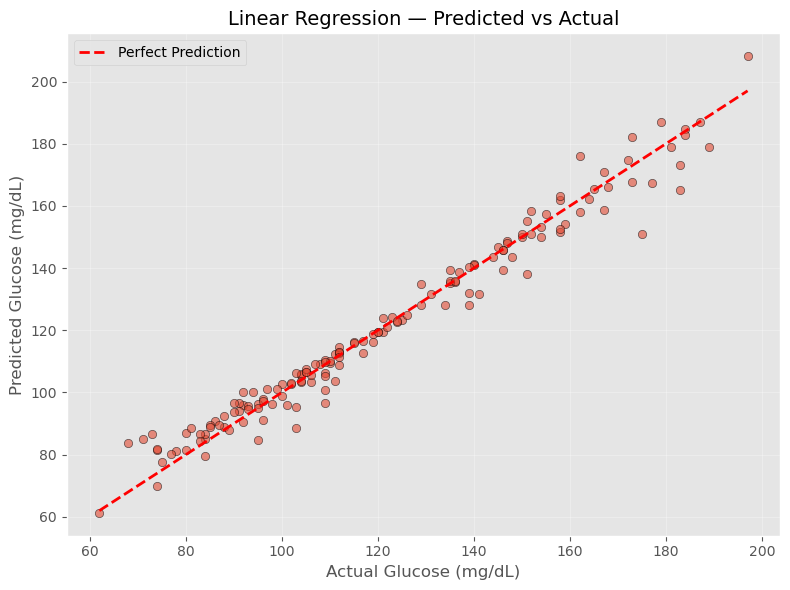

MAE: 3.84 mg/dL | RMSE: 5.56 mg/dL


In [6]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, lr_results['y_pred'], alpha=0.6, edgecolors='k')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Glucose (mg/dL)', fontsize=12)
ax.set_ylabel('Predicted Glucose (mg/dL)', fontsize=12)
ax.set_title('Linear Regression — Predicted vs Actual', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MAE: {lr_results['MAE']:.2f} mg/dL | RMSE: {lr_results['RMSE']:.2f} mg/dL")

In [7]:
ridge_param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid=ridge_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

print('⏳ Running Ridge GridSearchCV...')
ridge_grid.fit(X_train_scaled, y_train)
ridge_reg = ridge_grid.best_estimator_

print(f'✅ Best alpha: {ridge_grid.best_params_["alpha"]}')

ridge_results = evaluate_regressor('Ridge Regression', ridge_reg, X_test, y_test, use_scaled=True)

print('\n=== Ridge Regression Results ===')
print(f"MAE:       {ridge_results['MAE']:.2f} mg/dL")
print(f"RMSE:      {ridge_results['RMSE']:.2f} mg/dL")
print(f"R²:        {ridge_results['R²']:.4f}")
print(f"MAPE:      {ridge_results['MAPE (%)']:.2f}%")

joblib.dump(ridge_reg, '../models/regression/ridge_regression.pkl')
print('\n💾 Model saved → models/regression/ridge_regression.pkl')

⏳ Running Ridge GridSearchCV...
✅ Best alpha: 0.1

=== Ridge Regression Results ===
MAE:       3.84 mg/dL
RMSE:      5.56 mg/dL
R²:        0.9692
MAPE:      3.39%

💾 Model saved → models/regression/ridge_regression.pkl


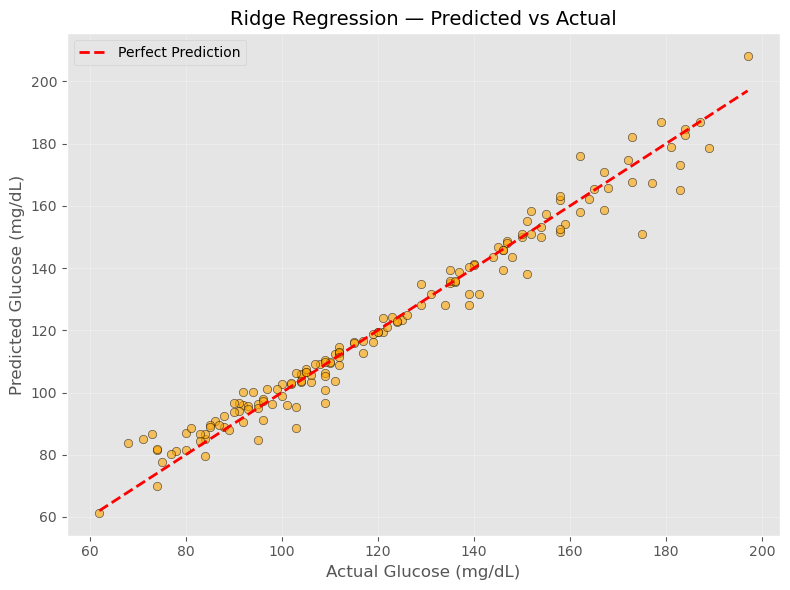

MAE: 3.84 mg/dL | RMSE: 5.56 mg/dL


In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, ridge_results['y_pred'], alpha=0.6, edgecolors='k', color='orange')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Glucose (mg/dL)', fontsize=12)
ax.set_ylabel('Predicted Glucose (mg/dL)', fontsize=12)
ax.set_title('Ridge Regression — Predicted vs Actual', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MAE: {ridge_results['MAE']:.2f} mg/dL | RMSE: {ridge_results['RMSE']:.2f} mg/dL")

In [9]:
lasso_param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

lasso_grid = GridSearchCV(
    Lasso(random_state=42, max_iter=5000),
    param_grid=lasso_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

print('⏳ Running Lasso GridSearchCV...')
lasso_grid.fit(X_train_scaled, y_train)
lasso_reg = lasso_grid.best_estimator_

print(f'✅ Best alpha: {lasso_grid.best_params_["alpha"]}')
print(f'   Features zeroed out: {(lasso_reg.coef_ == 0).sum()} / {len(lasso_reg.coef_)}')

lasso_results = evaluate_regressor('Lasso Regression', lasso_reg, X_test, y_test, use_scaled=True)

print('\n=== Lasso Regression Results ===')
print(f"MAE:       {lasso_results['MAE']:.2f} mg/dL")
print(f"RMSE:      {lasso_results['RMSE']:.2f} mg/dL")
print(f"R²:        {lasso_results['R²']:.4f}")
print(f"MAPE:      {lasso_results['MAPE (%)']:.2f}%")

joblib.dump(lasso_reg, '../models/regression/lasso_regression.pkl')
print('\n💾 Model saved → models/regression/lasso_regression.pkl')

⏳ Running Lasso GridSearchCV...
✅ Best alpha: 0.01
   Features zeroed out: 0 / 10

=== Lasso Regression Results ===
MAE:       3.84 mg/dL
RMSE:      5.56 mg/dL
R²:        0.9693
MAPE:      3.39%

💾 Model saved → models/regression/lasso_regression.pkl


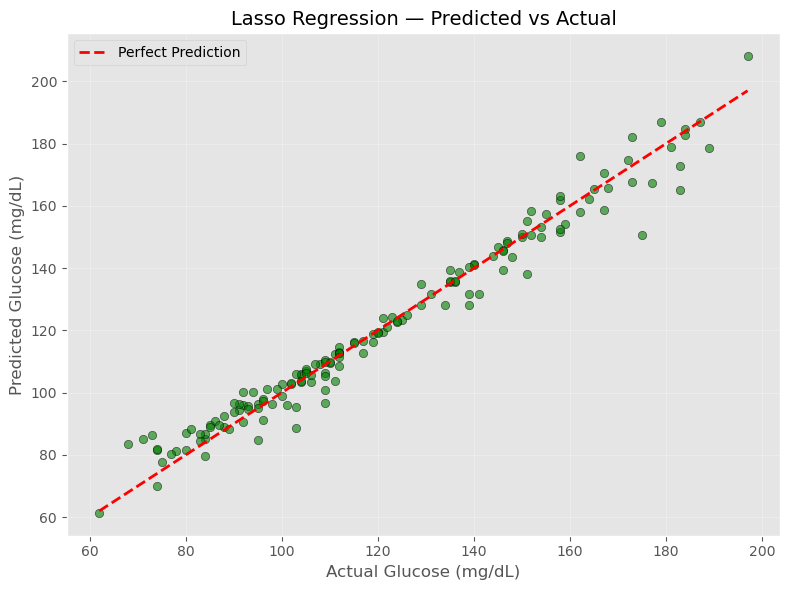

MAE: 3.84 mg/dL | RMSE: 5.56 mg/dL


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, lasso_results['y_pred'], alpha=0.6, edgecolors='k', color='green')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
        'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Glucose (mg/dL)', fontsize=12)
ax.set_ylabel('Predicted Glucose (mg/dL)', fontsize=12)
ax.set_title('Lasso Regression — Predicted vs Actual', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MAE: {lasso_results['MAE']:.2f} mg/dL | RMSE: {lasso_results['RMSE']:.2f} mg/dL")

In [11]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [5, 10]
}

rf_reg_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

print('⏳ Running Random Forest GridSearchCV...')
rf_reg_grid.fit(X_train, y_train)
rf_reg = rf_reg_grid.best_estimator_

print(f'\n✅ Best parameters:')
print(json.dumps(rf_reg_grid.best_params_, indent=2))

rf_results = evaluate_regressor('Random Forest', rf_reg, X_test, y_test, use_scaled=False)

print('\n=== Random Forest Results ===')
print(f"MAE:       {rf_results['MAE']:.2f} mg/dL")
print(f"RMSE:      {rf_results['RMSE']:.2f} mg/dL")
print(f"R²:        {rf_results['R²']:.4f}")
print(f"MAPE:      {rf_results['MAPE (%)']:.2f}%")

joblib.dump(rf_reg, '../models/regression/random_forest_regressor.pkl')
print('\n💾 Model saved → models/regression/random_forest_regressor.pkl')

⏳ Running Random Forest GridSearchCV...

✅ Best parameters:
{
  "max_depth": null,
  "min_samples_split": 5,
  "n_estimators": 200
}

=== Random Forest Results ===
MAE:       3.02 mg/dL
RMSE:      4.70 mg/dL
R²:        0.9781
MAPE:      2.45%

💾 Model saved → models/regression/random_forest_regressor.pkl


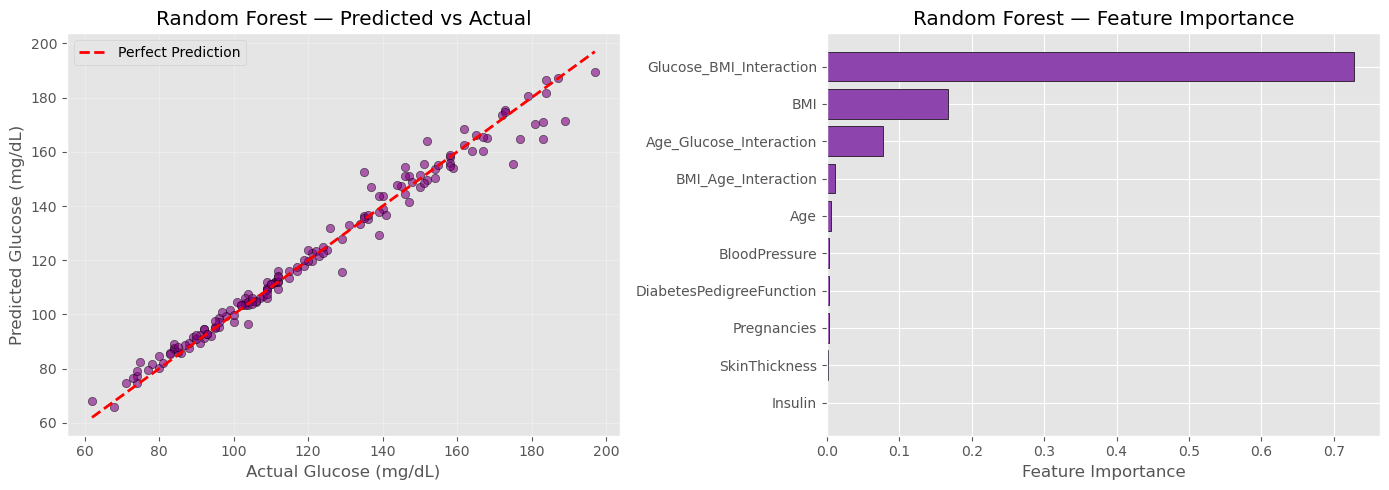

MAE: 3.02 mg/dL | RMSE: 4.70 mg/dL


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter
axes[0].scatter(y_test, rf_results['y_pred'], alpha=0.6, edgecolors='k', color='purple')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Glucose (mg/dL)')
axes[0].set_ylabel('Predicted Glucose (mg/dL)')
axes[0].set_title('Random Forest — Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Feature Importance
importances = rf_reg.feature_importances_
sorted_idx = np.argsort(importances)
axes[1].barh(X.columns[sorted_idx], importances[sorted_idx],
             color='#8e44ad', edgecolor='black')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Random Forest — Feature Importance')

plt.tight_layout()
plt.show()

print(f"MAE: {rf_results['MAE']:.2f} mg/dL | RMSE: {rf_results['RMSE']:.2f} mg/dL")

In [13]:
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8]
}

gb_reg_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

print('⏳ Running Gradient Boosting GridSearchCV...')
gb_reg_grid.fit(X_train, y_train)
gb_reg = gb_reg_grid.best_estimator_

print(f'\n✅ Best parameters:')
print(json.dumps(gb_reg_grid.best_params_, indent=2))

gb_results = evaluate_regressor('Gradient Boosting', gb_reg, X_test, y_test, use_scaled=False)

print('\n=== Gradient Boosting Results ===')
print(f"MAE:       {gb_results['MAE']:.2f} mg/dL")
print(f"RMSE:      {gb_results['RMSE']:.2f} mg/dL")
print(f"R²:        {gb_results['R²']:.4f}")
print(f"MAPE:      {gb_results['MAPE (%)']:.2f}%")

joblib.dump(gb_reg, '../models/regression/gradient_boosting.pkl')
print('\n💾 Model saved → models/regression/gradient_boosting.pkl')

⏳ Running Gradient Boosting GridSearchCV...

✅ Best parameters:
{
  "learning_rate": 0.05,
  "max_depth": 5,
  "n_estimators": 200,
  "subsample": 0.8
}

=== Gradient Boosting Results ===
MAE:       2.44 mg/dL
RMSE:      3.60 mg/dL
R²:        0.9871
MAPE:      1.99%

💾 Model saved → models/regression/gradient_boosting.pkl


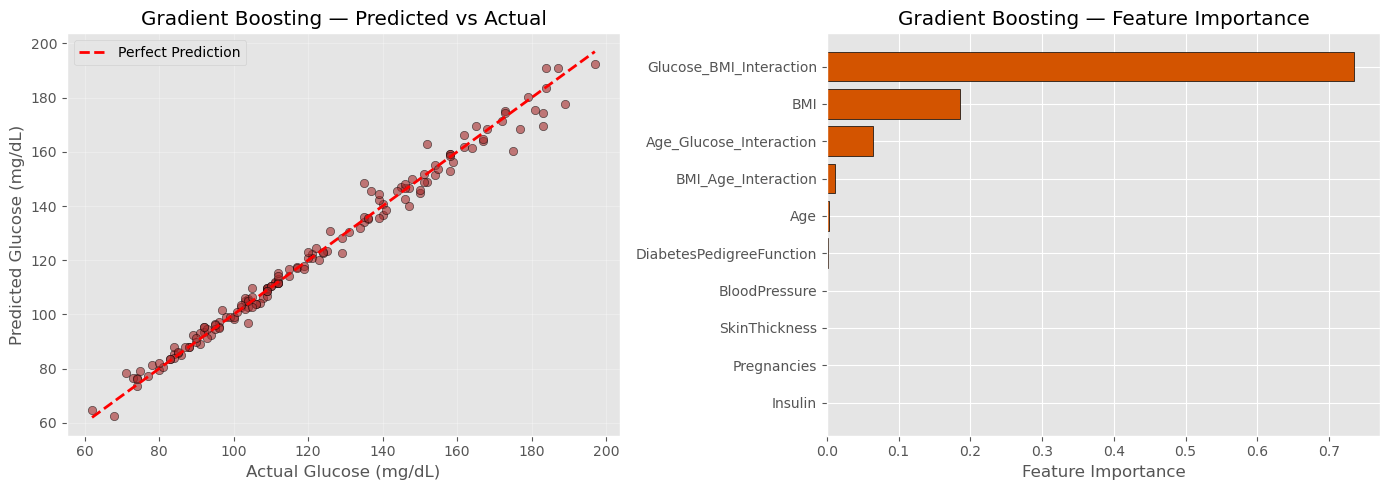

MAE: 2.44 mg/dL | RMSE: 3.60 mg/dL


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter
axes[0].scatter(y_test, gb_results['y_pred'], alpha=0.6, edgecolors='k', color='brown')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Glucose (mg/dL)')
axes[0].set_ylabel('Predicted Glucose (mg/dL)')
axes[0].set_title('Gradient Boosting — Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Feature Importance
importances = gb_reg.feature_importances_
sorted_idx = np.argsort(importances)
axes[1].barh(X.columns[sorted_idx], importances[sorted_idx],
             color='#d35400', edgecolor='black')
axes[1].set_xlabel('Feature Importance')
axes[1].set_title('Gradient Boosting — Feature Importance')

plt.tight_layout()
plt.show()

print(f"MAE: {gb_results['MAE']:.2f} mg/dL | RMSE: {gb_results['RMSE']:.2f} mg/dL")

In [15]:
all_results = [lr_results, ridge_results, lasso_results, rf_results, gb_results]

comparison = []
for r in all_results:
    comparison.append({
        'Model':    r['Model'],
        'MAE':      round(r['MAE'], 2),
        'RMSE':     round(r['RMSE'], 2),
        'R²':       round(r['R²'], 4),
        'MAPE (%)': round(r['MAPE (%)'], 2)
    })

df_comparison = pd.DataFrame(comparison).set_index('Model')

display_df = df_comparison.copy().astype(str)

for col in ['MAE', 'RMSE', 'MAPE (%)']:
    best_idx = df_comparison[col].idxmin()
    display_df.loc[best_idx, col] = display_df.loc[best_idx, col] + ' ★'

best_r2_idx = df_comparison['R²'].idxmax()
display_df.loc[best_r2_idx, 'R²'] = display_df.loc[best_r2_idx, 'R²'] + ' ★'

print('='*70)
print('  REGRESSION MODEL COMPARISON')
print('  ★ = best score (lowest for MAE/RMSE/MAPE, highest for R²)')
print('='*70)
print(display_df.to_string())
print('='*70)

  REGRESSION MODEL COMPARISON
  ★ = best score (lowest for MAE/RMSE/MAPE, highest for R²)
                      MAE   RMSE        R² MAPE (%)
Model                                              
Linear Regression    3.84   5.56    0.9693     3.39
Ridge Regression     3.84   5.56    0.9692     3.39
Lasso Regression     3.84   5.56    0.9693     3.39
Random Forest        3.02    4.7    0.9781     2.45
Gradient Boosting  2.44 ★  3.6 ★  0.9871 ★   1.99 ★


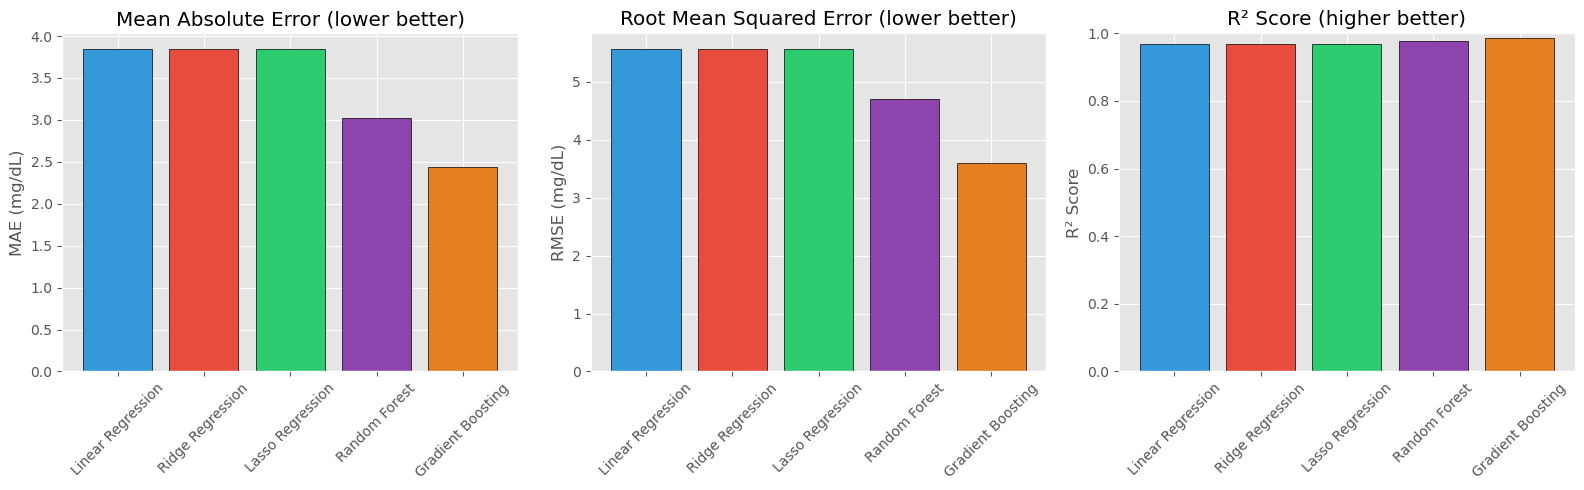

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = df_comparison.index
colors = ['#3498db', '#e74c3c', '#2ecc71', '#8e44ad', '#e67e22']

axes[0].bar(models, df_comparison['MAE'], color=colors, edgecolor='black')
axes[0].set_ylabel('MAE (mg/dL)')
axes[0].set_title('Mean Absolute Error (lower better)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(models, df_comparison['RMSE'], color=colors, edgecolor='black')
axes[1].set_ylabel('RMSE (mg/dL)')
axes[1].set_title('Root Mean Squared Error (lower better)')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(models, df_comparison['R²'], color=colors, edgecolor='black')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score (higher better)')
axes[2].set_ylim([0, 1])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [17]:
ranked = sorted(all_results, key=lambda r: r['MAE'])
best = ranked[0]

print('🏆 BEST REGRESSOR')
print(f"   Model: {best['Model']}")
print(f"   MAE:       {best['MAE']:.2f} mg/dL")
print(f"   RMSE:      {best['RMSE']:.2f} mg/dL")
print(f"   R²:        {best['R²']:.4f}")
print(f"   MAPE:      {best['MAPE (%)']:.2f}%")

if best['Model'] == 'Linear Regression':
    best_model_obj = lr_reg
elif best['Model'] == 'Ridge Regression':
    best_model_obj = ridge_reg
elif best['Model'] == 'Lasso Regression':
    best_model_obj = lasso_reg
elif best['Model'] == 'Random Forest':
    best_model_obj = rf_reg
else:
    best_model_obj = gb_reg

joblib.dump(best_model_obj, '../models/regression/best_regressor.pkl')
print('\n💾 Best model saved → models/regression/best_regressor.pkl')

🏆 BEST REGRESSOR
   Model: Gradient Boosting
   MAE:       2.44 mg/dL
   RMSE:      3.60 mg/dL
   R²:        0.9871
   MAPE:      1.99%

💾 Best model saved → models/regression/best_regressor.pkl


In [18]:
report = {
    'experiment': 'regression',
    'target': 'Glucose (mg/dL)',
    'dataset': {
        'total_samples': 768,
        'train_samples': len(y_train),
        'test_samples': len(y_test),
        'features': X.shape[1]
    },
    'selected_model': best['Model'],
    'selection_criteria': 'Lowest MAE',
    'all_models': []
}

for r in all_results:
    report['all_models'].append({
        'model': r['Model'],
        'mae': float(r['MAE']),
        'rmse': float(r['RMSE']),
        'r2': float(r['R²']),
        'mape': float(r['MAPE (%)'])
    })

os.makedirs('../reports', exist_ok=True)
with open('../reports/regression_results.json', 'w') as f:
    json.dump(report, f, indent=2)

print('📄 Results report saved → reports/regression_results.json')

📄 Results report saved → reports/regression_results.json
